In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from pathlib import Path

import numpy as np
import ampyl
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

import KKpi_A1PLUS_helper as helper

warnings.simplefilter('ignore')

## Construct the $K K \pi$ index space

This example traces the ground state of the maximal-isospin $K K \pi$ system ($I = 2$) in the $A_1^+$ irrep at zero total momentum. Masses are given in units of the pion mass, with $m_K/m_\pi = 0.09698/0.06906 \approx 1.404$ taken from a typical lattice setup.

The flavor channel has two spectator channels, one in which the kaon spectates while $K \pi$ scatter with $I_{K \pi} = 3/2$ and one in which the pion spectates while $K K$ scatter with $I_{K K} = 1$. Both two-particle channels are restricted to S-wave interactions.

Three implementation options are set in the finite-volume setup: `smarter_q_rescale` and `include_H_in_IPV` improve the smoothness of the $F + G$ matrix, making it easier to interpolate, and `discard_non_interacting` removes directions of the index space that decouple from the interacting solutions.

_Evaluating the following cell takes ~ 10-20 seconds on a MacBook Air (M1, 2020)_

In [3]:
pion = ampyl.flavor.Particle(mass=helper.MPI, spin=0., flavor='pi',
                             isospin_multiplet=True, isospin=1.)
kaon = ampyl.flavor.Particle(mass=helper.MK, spin=0., flavor='K',
                             isospin_multiplet=True, isospin=0.5)
fc = ampyl.flavor.FlavorChannel(3, particles=[kaon, kaon, pion], isospin=2.)
fcs = ampyl.flavor.FlavorChannelSpace(fc_list=[fc], ni_list=[fc])
fvs = ampyl.spaces.FiniteVolumeSetup(qc_impl={'smarter_q_rescale': True,
                                              'include_H_in_IPV': True,
                                              'discard_non_interacting': True})
tbis = ampyl.spaces.ThreeBodyInteractionScheme(fcs=fcs)

qcis = ampyl.spaces.QCIndexSpace(fcs=fcs, fvs=fvs, tbis=tbis,
                                 Emax=4.0, Lmax=6.1)
qcis.populate()
print(qcis.proj_dict['summary'])

kellm space has size 26

    A1PLUS  covers 5x1 = 5 slots
    EPLUS   covers 3x2 = 6 slots
    T2PLUS  covers 1x3 = 3 slots
    T1MINUS covers 3x3 = 9 slots
    T2MINUS covers 1x3 = 3 slots

total is 26 
total matches size of kellm space


## Build the $F + G$ interpolator

Root-finding on the quantization condition requires many evaluations of the finite-volume matrix $F + G$, and evaluating this directly at every $(E, L)$ dominates the cost. The helper's `build_qc` therefore builds a single spline interpolator of the pole-free part of $F + G$ over an $(E, L)$ window covering the ground state. (The small offset in `Emin` keeps the grid away from the pole at the $K K \pi$ threshold, $E = 2 m_K + m_\pi$.)

When `precomputed_dir` is provided and `dill` is installed, the interpolator is saved to the directory on the first build and re-loaded on later runs. (The `precomputed/` directory is not tracked by git.)

_Building the interpolator from scratch takes ~ 30-60 seconds on a MacBook Air (M1, 2020); with a cached version this reduces to a few seconds_

In [4]:
project = True
irrep = ('A1PLUS', 0)
grid = {'Emin': helper.EMIN-0.1000123, 'Emax': 3.95, 'dE': 0.01,
        'Lmin': 3.5, 'Lmax': 6.0, 'dL': 0.05}

qc = helper.build_qc(qcis, grid, project, irrep,
                     precomputed_dir='precomputed')

## Evaluate the $K K \pi$ quantization condition

The K-matrix parameters are passed using `k_params`. In this case we have a single flavor channel with two spectator channels, each described by a single scattering length ($a_{K \pi}$ and $a_{K K}$). The three-particle K-matrix is set to zero by the QC version `'kdf_zero_1+_fgcombo'`, entered in the evaluation policy within `helper.make_qc_dict`.

This leads to the following structure for `k_params`:

`k_params = [[[a_Kpi], [a_KK]], [alpha]]`,

where `alpha` parametrizes the (here unused) three-particle K-matrix. Both scattering lengths are set to small positive (repulsive) values.

The zero-crossing in the plot below is the interacting ground state, sitting just above the non-interacting energy $E_{0, {\sf ni}} = 2 m_K + m_\pi$, in which all three particles are at rest.

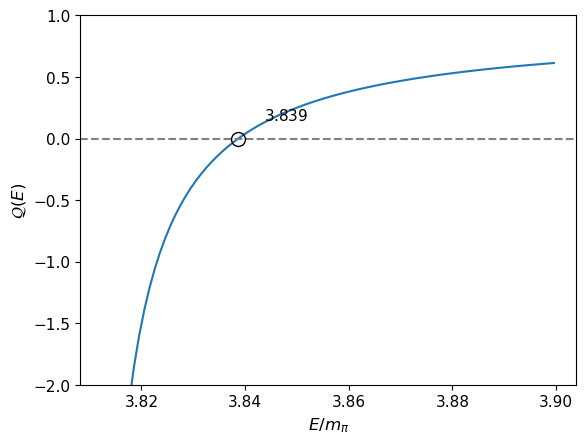

In [5]:
mk = helper.MK
E_ni = 2.0*mk+1.0
scattering_lengths = [0.04/mk, 0.038/mk]
qc_dict = helper.make_qc_dict(qc, scattering_lengths, project, irrep)

L = 4.5
E_vals = np.arange(E_ni+0.004, 3.9, 0.001)
qc_vals = []
for E in E_vals:
    qc_tmp = qc.get_value(E=float(E), L=L, qc_dict=qc_dict)
    qc_vals = qc_vals+[qc_tmp]
qc_vals = np.array(qc_vals)
root = root_scalar(qc.get_value, args=(L, qc_dict),
                   bracket=[E_ni+0.008, E_ni+0.1]).root

plt.plot(E_vals, qc_vals)
plt.axhline(y=0, color='0.5', linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel(r'$E/m_\pi$', fontsize=12)
plt.ylabel(r'${\cal Q}(E)$', fontsize=12)
plt.plot(root, 0, 'o', markersize=10, markeredgecolor='k',
         markerfacecolor='none')
plt.text(root+0.005, 0.15, f'${root:.3f}$', fontsize=11)
plt.ylim(-2., 1.)
plt.show()

## Evaluate $E_0(L)$ vs $L$

The final step is to use `root_scalar` to find the ground state as a function of $L$. The solution is bracketed using the non-interacting energy, which here is independent of $L$. As the interactions are repulsive, the ground state is shifted upward, with the shift falling like $1/L^3$ at large volume.

In [6]:
L_vals = np.arange(3.6, 6.0, 0.1)
E0_vals = []
for L in L_vals:
    sol_tmp = root_scalar(qc.get_value, args=(float(L), qc_dict),
                          bracket=[E_ni+0.008, E_ni+0.1]).root
    E0_vals = E0_vals+[sol_tmp]
E0_vals = np.array(E0_vals)

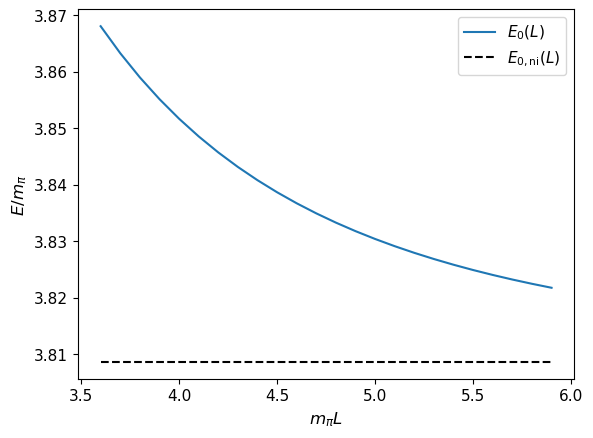

In [7]:
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)

plt.plot(L_vals, E0_vals)
plt.plot(L_vals, 0.0*L_vals+E_ni, 'k--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel(r'$m_\pi L$', fontsize=12)
plt.ylabel(r'$E/m_\pi$', fontsize=12)
plt.legend([r'$E_0(L)$', r'$E_{0, {\sf ni}}(L)$'], fontsize=11)
plt.savefig(output_dir/'KKpi_A1PLUS_ground_state.pdf', bbox_inches='tight')
plt.show()